# 02 — Process and validate IQM experimental data

This notebook reconstructs per-qubit excited-state populations from the archived IQM sweep results, then computes the ensemble mean and standard error of the mean (SEM) across qubits. Panels A/B store one array per qubit in `(shot, circuit, sweep)` order. Panels C/D store one array per sweep point and qubit, with `(shot, circuit)` ordering within each array and forward sweep order. The resulting tables and two PDF figures covering panels A–D document the reconstruction.


In [1]:
from __future__ import annotations

import json
import re
from itertools import cycle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path(".").resolve()
RAW_ROOT = REPO_ROOT / "data" / "raw" / "iqm_jobs"
META_ROOT = REPO_ROOT / "metadata"
PROCESSED_ROOT = REPO_ROOT / "data" / "processed"
PER_QUBIT_ROOT = PROCESSED_ROOT / "per_qubit"
SUMMARY_ROOT = PROCESSED_ROOT / "figure_data"
FIGURES_ROOT = REPO_ROOT / "figures"

for directory in (PER_QUBIT_ROOT, SUMMARY_ROOT, FIGURES_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

SHOTS = 1024

AMP_EPS_VALUES = np.linspace(-0.20, 0.20, 31)
DETUNING_VALUES_HZ = np.linspace(-9e6, 9e6, 41)

PANEL_CONFIGS = {
    "A": {
        "mode": "amplitude",
        "x": AMP_EPS_VALUES,
        "x_column": "epsilon",
        "x_label": r"Rabi-frequency error $\epsilon$",
        "fixed_epsilon": None,
        "fixed_detuning_hz": 0.0,
        "storage": "embedded_sweep",
    },
    "B": {
        "mode": "amplitude",
        "x": AMP_EPS_VALUES,
        "x_column": "epsilon",
        "x_label": r"Rabi-frequency error $\epsilon$",
        "fixed_epsilon": None,
        "fixed_detuning_hz": 2.5e6,
        "storage": "embedded_sweep",
    },
    "C": {
        "mode": "detuning",
        "x": DETUNING_VALUES_HZ,
        "x_column": "detuning_MHz",
        "x_label": r"Detuning error $\Delta$ [MHz]",
        "fixed_epsilon": 0.0,
        "fixed_detuning_hz": None,
        "storage": "split_sweep",
    },
    "D": {
        "mode": "detuning",
        "x": DETUNING_VALUES_HZ,
        "x_column": "detuning_MHz",
        "x_label": r"Detuning error $\Delta$ [MHz]",
        "fixed_epsilon": 0.07,
        "fixed_detuning_hz": None,
        "storage": "split_sweep",
    },
}

job_manifest = pd.read_csv(META_ROOT / "job_manifest.csv")
display(job_manifest)


,job_id,family,panel,description
0,01a0a57b-b833-7df0-849c-915f92f8545b,d,A,"Amplitude sweep, Delta = 0"
1,01a0a57d-16d2-7f11-b33e-adf02b8d55fd,d,B,"Amplitude sweep, Delta = 2.5 MHz"
2,01a0a57e-4c4f-7f82-af6d-66730fad5648,d,C,"Delta sweep, eps = 0"
3,01a0a57f-e612-73a0-a4c0-523ced5dc57c,d,D,"Delta sweep, eps = 0.07"
4,01a072a2-2420-7832-9e14-2cdcc10719b2,a,A,"Amplitude sweep, Delta = 0"
5,01a072a3-8b43-7750-ac81-2431b9de5abb,a,B,"Amplitude sweep, Delta = 2.5 MHz"
6,01a072a4-ca2f-7a62-a49e-a7eeaa1b8e17,a,C,"Delta sweep, eps = 0"
7,01a072a6-658d-79f3-bff1-2e7fd0670b76,a,D,"Delta sweep, eps = 0.07"
8,01a0a594-d17f-7f32-a6dc-5cd1766b125b,s,A,"Amplitude sweep, Delta = 0"
9,01a0a596-3bc5-7d41-975d-df578aa622f5,s,B,"Amplitude sweep, Delta = 2.5 MHz"


## Circuit order

The six circuits in each family comprise the native half-rotation followed by five composite sequences. Labels follow the original circuit order.


In [2]:
CIRCUITS_BY_FAMILY = {
    "d": [
        "standard_pi_2", "UVH4d", "UVH5d", "UVH6d", "UVH7d", "UVH8d",
    ],
    "a": [
        "standard_pi_2", "UVH4a", "UVH5a", "UVH6a", "UVH7a", "UVH8a",
    ],
    "s": [
        "standard_pi_2", "UVH5s", "UVH7s", "UVH9s", "UVH11s", "UVH13s",
    ],
}


def circuit_labels(record):
    return CIRCUITS_BY_FAMILY[str(record["family"])]


In [3]:
MEASUREMENT_KEY = re.compile(
    r"^(?P<qubit>QB\d+)__c_(?P<n_qubits>\d+)_(?P<group>\d+)_(?P<logical_q>\d+)$"
)


def load_raw_arrays(job_id):
    job_dir = RAW_ROOT / str(job_id)
    index = json.loads(
        (job_dir / "sweep_results_index.json").read_text(encoding="utf-8")
    )
    npz = np.load(job_dir / "sweep_results.npz", allow_pickle=False)

    records = []

    for parameter, entries in index["parameters"].items():
        match = MEASUREMENT_KEY.match(parameter)
        if match is None:
            raise ValueError(f"Unexpected IQM result parameter: {parameter}")

        arrays = [
            np.asarray(npz[entry["npz_key"]], dtype=float)
            for entry in entries
        ]

        records.append({
            "parameter": parameter,
            "qubit": match.group("qubit"),
            "logical_q": int(match.group("logical_q")),
            "n_qubits_encoded": int(match.group("n_qubits")),
            "arrays": arrays,
        })

    return sorted(records, key=lambda item: item["logical_q"])


In [4]:
def validate_raw_job(record, labels):
    panel = str(record["panel"])
    cfg = PANEL_CONFIGS[panel]

    raw = load_raw_arrays(record["job_id"])
    n_qubits = len(raw)
    n_circuits = len(labels)
    n_sweep = len(cfg["x"])

    logical = [item["logical_q"] for item in raw]
    if logical != list(range(n_qubits)):
        raise ValueError("Logical-qubit indices are incomplete or out of order.")

    if {item["n_qubits_encoded"] for item in raw} != {n_qubits}:
        raise ValueError("IQM result keys and recovered qubit count disagree.")

    for item in raw:
        arrays = item["arrays"]

        if cfg["storage"] == "embedded_sweep":
            if len(arrays) != 1:
                raise ValueError(
                    f"Panel {panel}: expected one raw array per qubit."
                )
            expected = SHOTS * n_circuits * n_sweep
            if arrays[0].size != expected:
                raise ValueError(
                    f"{item['qubit']}: got {arrays[0].size} values; "
                    f"expected {expected}."
                )

        else:
            if len(arrays) != n_sweep:
                raise ValueError(
                    f"Panel {panel}: expected {n_sweep} sweep arrays per qubit."
                )
            expected = SHOTS * n_circuits
            if any(array.size != expected for array in arrays):
                raise ValueError(
                    f"{item['qubit']}: unexpected split-sweep array size."
                )

        values = np.concatenate([array.reshape(-1) for array in arrays])
        if not np.all(np.isclose(values, 0.0) | np.isclose(values, 1.0)):
            raise ValueError(f"{item['qubit']}: non-binary measurement values.")

    return {
        "job_id": record["job_id"],
        "panel": panel,
        "n_qubits": n_qubits,
        "n_circuits": n_circuits,
        "n_sweep": n_sweep,
        "shots": SHOTS,
        "storage": cfg["storage"],
    }


In [5]:
def canonical_measurements(item, panel, n_circuits):
    cfg = PANEL_CONFIGS[panel]
    n_sweep = len(cfg["x"])

    if cfg["storage"] == "embedded_sweep":
        return (
            item["arrays"][0]
            .reshape(SHOTS, n_circuits, n_sweep)
            .transpose(1, 2, 0)
        )

    per_sweep = [
        array.reshape(SHOTS, n_circuits).T
        for array in item["arrays"]
    ]
    return np.stack(per_sweep, axis=1)


def decode_job(record, labels):
    panel = str(record["panel"])
    cfg = PANEL_CONFIGS[panel]
    raw = load_raw_arrays(record["job_id"])

    validate_raw_job(record, labels)

    rows = []

    for item in raw:
        data = canonical_measurements(item, panel, len(labels))

        for circuit_idx, label in enumerate(labels):
            for sweep_idx, x_value in enumerate(cfg["x"]):
                shots_vector = data[circuit_idx, sweep_idx]
                n1 = int(np.rint(shots_vector).sum())
                p1 = n1 / SHOTS

                if cfg["mode"] == "amplitude":
                    epsilon = float(x_value)
                    detuning_hz = float(cfg["fixed_detuning_hz"])
                else:
                    epsilon = float(cfg["fixed_epsilon"])
                    detuning_hz = float(x_value)

                rows.append({
                    "job_id": record["job_id"],
                    "family": record["family"],
                    "panel": panel,
                    "qubit": item["qubit"],
                    "logical_q": item["logical_q"],
                    "circuit_idx": circuit_idx,
                    "circuit": label,
                    "sweep_idx": sweep_idx,
                    "epsilon": epsilon,
                    "detuning_Hz": detuning_hz,
                    "detuning_MHz": detuning_hz / 1e6,
                    "n1": n1,
                    "shots": SHOTS,
                    "p1_raw": p1,
                })

    return pd.DataFrame(rows)


In [6]:
def aggregate_job(per_qubit):
    group_columns = [
        "job_id",
        "family",
        "panel",
        "circuit_idx",
        "circuit",
        "sweep_idx",
        "epsilon",
        "detuning_Hz",
        "detuning_MHz",
    ]

    def summarize(group):
        p1 = group["p1_raw"].to_numpy(float)
        n_qubits = len(p1)
        sample_std = np.std(p1, ddof=1) if n_qubits > 1 else np.nan

        return pd.Series({
            "n_qubits": n_qubits,
            "p1_mean": np.mean(p1),
            "sample_std_across_qubits": sample_std,
            "sem_across_qubits": sample_std / np.sqrt(n_qubits),
        })

    return (
        per_qubit
        .groupby(group_columns, as_index=False, dropna=False)
        .apply(summarize)
        .reset_index(drop=True)
        .sort_values(["circuit_idx", "sweep_idx"])
        .reset_index(drop=True)
    )


## Processed data

The per-qubit tables retain the individual measurement counts. The summary tables report the mean, sample standard deviation, and SEM across qubits for each circuit and sweep point.


In [7]:
summaries = {}
validation_rows = []

for _, record in job_manifest.iterrows():
    record = record.to_dict()
    labels = circuit_labels(record)

    audit = validate_raw_job(record, labels)
    per_qubit = decode_job(record, labels)
    summary = aggregate_job(per_qubit)

    job_id = str(record["job_id"])

    per_qubit.to_csv(
        PER_QUBIT_ROOT / f"{job_id}.csv",
        index=False,
    )
    summary.to_csv(
        SUMMARY_ROOT / f"{job_id}.csv",
        index=False,
    )

    summaries[job_id] = summary

    validation_rows.append(audit)

validation_report = pd.DataFrame(validation_rows)
validation_report.to_csv(
    PROCESSED_ROOT / "validation_report.csv",
    index=False,
)

display(validation_report)


,job_id,panel,n_qubits,n_circuits,n_sweep,shots,storage
0,01a0a57b-b833-7df0-849c-915f92f8545b,A,20,6,31,1024,embedded_sweep
1,01a0a57d-16d2-7f11-b33e-adf02b8d55fd,B,20,6,31,1024,embedded_sweep
2,01a0a57e-4c4f-7f82-af6d-66730fad5648,C,20,6,41,1024,split_sweep
3,01a0a57f-e612-73a0-a4c0-523ced5dc57c,D,20,6,41,1024,split_sweep
4,01a072a2-2420-7832-9e14-2cdcc10719b2,A,20,6,31,1024,embedded_sweep
5,01a072a3-8b43-7750-ac81-2431b9de5abb,B,20,6,31,1024,embedded_sweep
6,01a072a4-ca2f-7a62-a49e-a7eeaa1b8e17,C,20,6,41,1024,split_sweep
7,01a072a6-658d-79f3-bff1-2e7fd0670b76,D,20,6,41,1024,split_sweep
8,01a0a594-d17f-7f32-a6dc-5cd1766b125b,A,20,6,31,1024,embedded_sweep
9,01a0a596-3bc5-7d41-975d-df578aa622f5,B,20,6,31,1024,embedded_sweep


## Validation figures

All three sequence families are plotted with per-point SEM error bars across qubits. The dashed line marks half population. Panels A/B and C/D are exported as separate PDF figures.


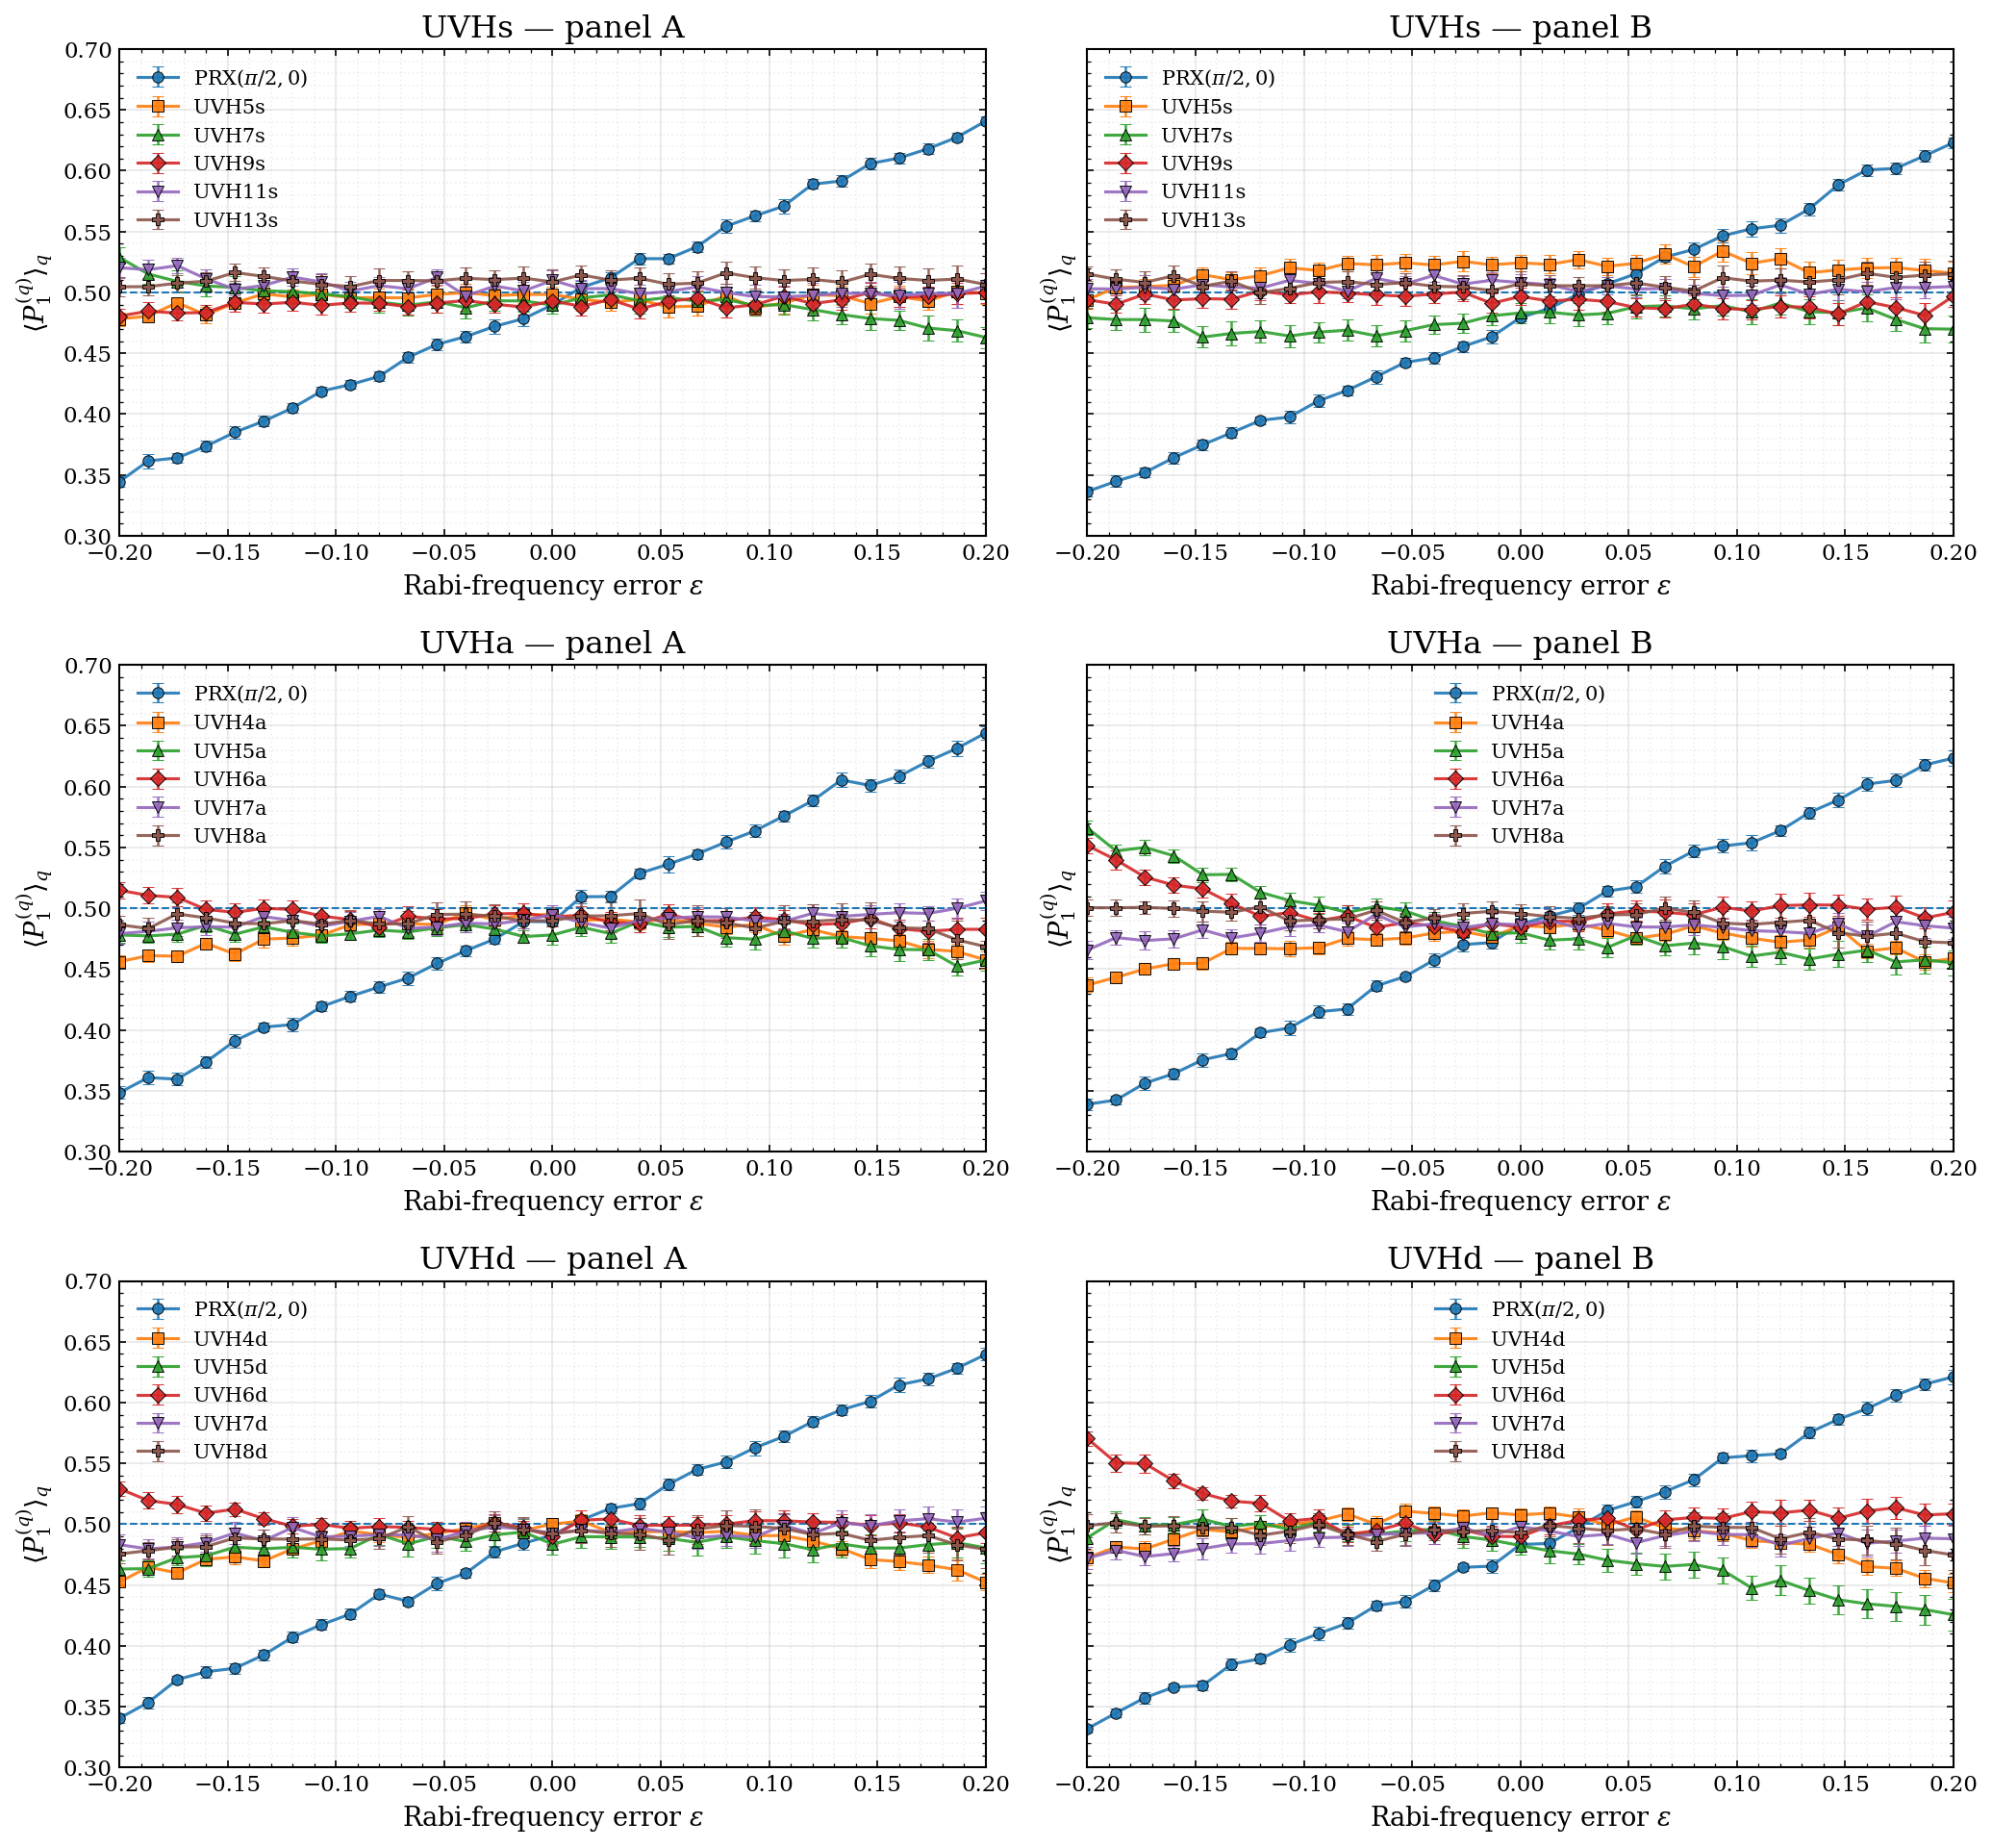

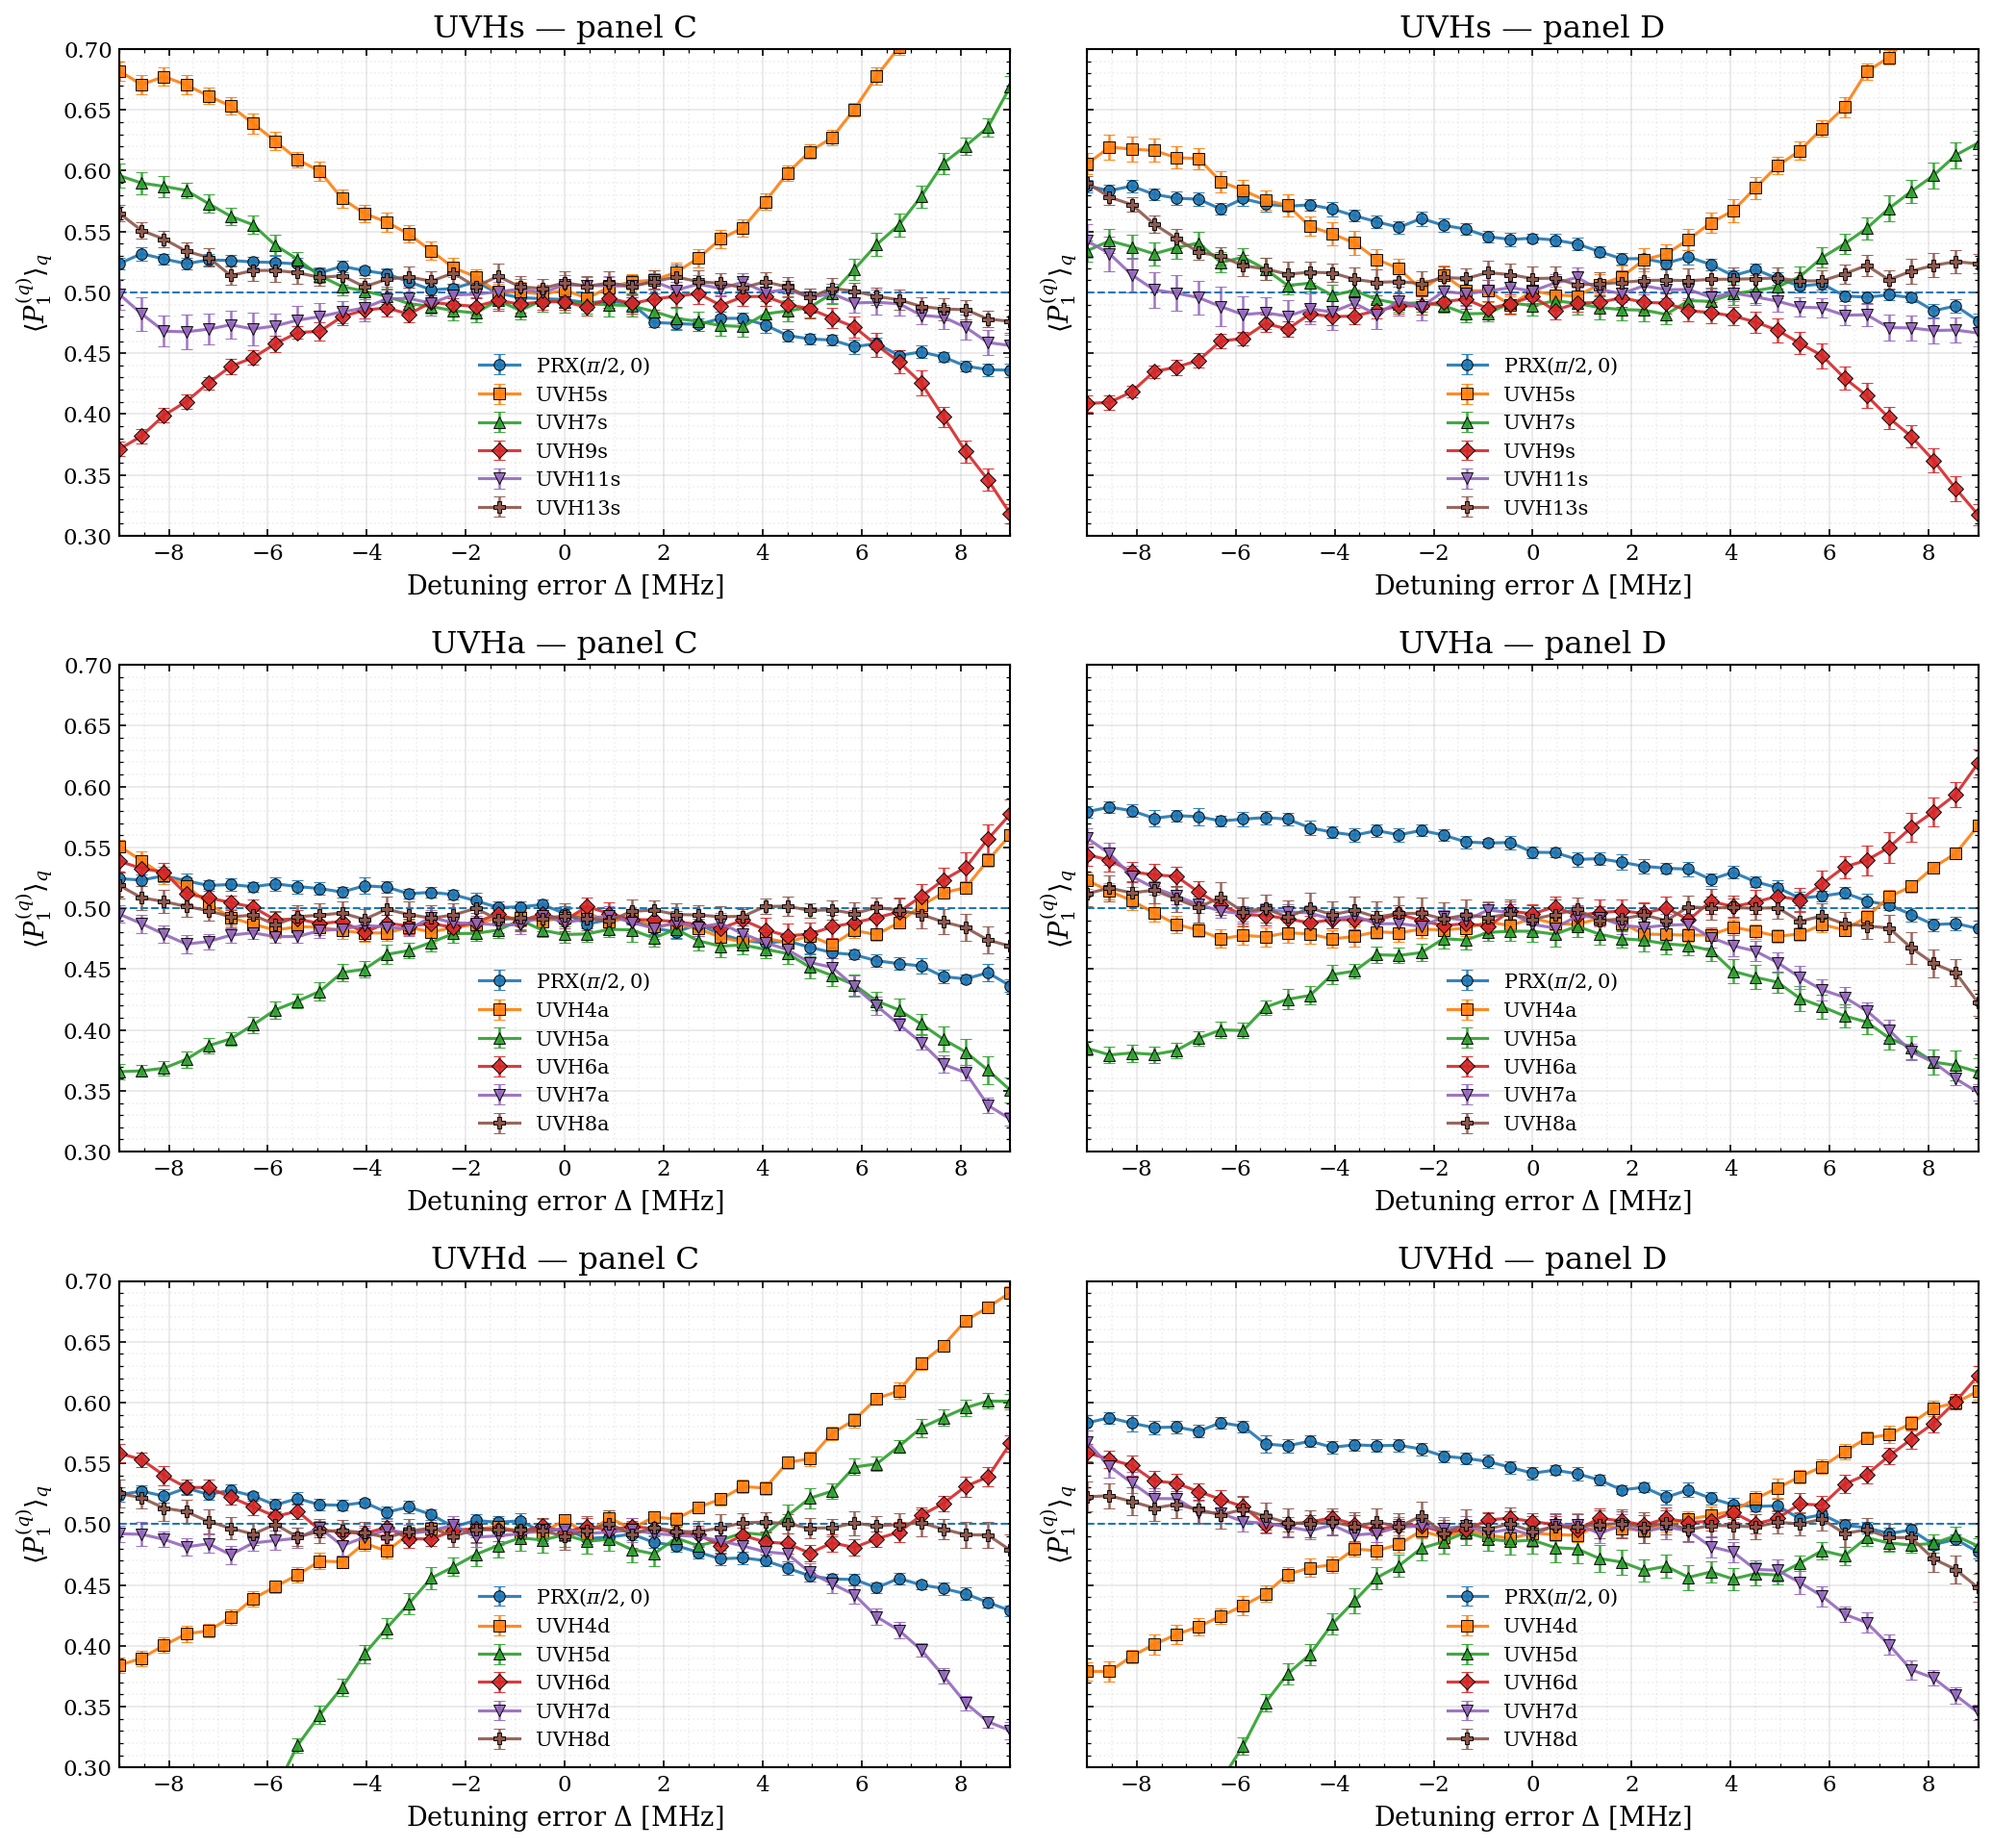

In [10]:
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.labelsize": 13,
    "font.size": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.0,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

MARKERS = ("o", "s", "^", "D", "v", "P", "X", "<", ">", "h", "*")
FAMILY_LABELS = {"s": "UVHs", "a": "UVHa", "d": "UVHd"}
FAMILY_ORDER = ("s", "a", "d")


def plot_label(label):
    if label == "standard_pi_2":
        return r"PRX($\pi/2,0$)"
    return str(label)


job_lookup = job_manifest.set_index(["family", "panel"])
if not job_lookup.index.is_unique:
    raise ValueError("The job manifest contains duplicate family/panel entries.")

for panels, filename in (
    (("A", "B"), "validation_panels_A_B.pdf"),
    (("C", "D"), "validation_panels_C_D.pdf"),
):
    fig, axes = plt.subplots(
        3, 2, figsize=(14, 13), sharey=True
    )

    for row, family in enumerate(FAMILY_ORDER):
        for col, panel in enumerate(panels):
            ax = axes[row, col]
            record = job_lookup.loc[(family, panel)]
            summary = summaries[str(record["job_id"])]
            cfg = PANEL_CONFIGS[panel]

            labels = (
                summary[["circuit_idx", "circuit"]]
                .drop_duplicates()
                .sort_values("circuit_idx")["circuit"]
                .tolist()
            )
            marker_by_circuit = {
                label: marker
                for label, marker in zip(labels, cycle(MARKERS))
            }

            for circuit, subset in summary.groupby("circuit", sort=False):
                subset = subset.sort_values("sweep_idx")
                ax.errorbar(
                    subset[cfg["x_column"]],
                    subset["p1_mean"],
                    yerr=subset["sem_across_qubits"],
                    marker=marker_by_circuit[circuit],
                    linestyle="-",
                    linewidth=1.5,
                    capsize=3,
                    capthick=1.2,
                    elinewidth=1.2,
                    markersize=5.5,
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    label=plot_label(circuit),
                    alpha=0.9,
                )

            ax.axhline(0.5, linestyle="--", linewidth=1.0)
            ax.set_xlabel(cfg["x_label"])
            ax.set_ylabel(r"$\langle P_1^{(q)}\rangle_q$")
            ax.set_ylim(0.3, 0.7)
            ax.set_xlim(
                summary[cfg["x_column"]].min(),
                summary[cfg["x_column"]].max(),
            )
            ax.minorticks_on()
            ax.grid(True, which="major", linestyle="-", alpha=0.3)
            ax.grid(True, which="minor", linestyle=":", alpha=0.2)
            ax.set_title(f"{FAMILY_LABELS[family]} — panel {panel}")
            ax.legend(frameon=False, loc="best")

    fig.tight_layout()
    pdf_path = FIGURES_ROOT / filename
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()


## Individual-qubit results

The excited-state populations are shown separately for each physical qubit, using the same circuit order and sweep conditions as the ensemble figures. Each qubit has two figures: panels A/B (amplitude sweeps) and panels C/D (detuning sweeps), with rows for the UVHs, UVHa, and UVHd sequence families.

Error bars show the binomial standard error, $\sqrt{P_1(1-P_1)/N}$, from the $N$ measurement shots at each point. They describe shot noise within a qubit; the ensemble figures use the SEM across qubits. The dashed line marks half population. A common population range of 0–1 is used for all individual-qubit panels.

Figures are saved at 300 dpi in `Individual_qubits/` beside this notebook, with the physical-qubit label and panel pair in each filename.


In [12]:
INDIVIDUAL_QUBITS_ROOT = REPO_ROOT / "Individual_qubits"
INDIVIDUAL_QUBITS_ROOT.mkdir(parents=True, exist_ok=True)

individual_data = {
    str(job_id): pd.read_csv(PER_QUBIT_ROOT / f"{job_id}.csv")
    for job_id in job_manifest["job_id"]
}
qubits_by_job = {
    job_id: set(table["qubit"])
    for job_id, table in individual_data.items()
}
qubits = sorted(
    set.union(*qubits_by_job.values()),
    key=lambda qubit: int(qubit.removeprefix("QB")),
)
if any(qubit_set != set(qubits) for qubit_set in qubits_by_job.values()):
    raise ValueError("The physical-qubit sets differ between archived jobs.")

for qubit in qubits:
    for panels, filename in (
        (("A", "B"), f"{qubit}_validation_panels_A_B.png"),
        (("C", "D"), f"{qubit}_validation_panels_C_D.png"),
    ):
        fig, axes = plt.subplots(3, 2, figsize=(14, 13), sharey=True)

        for row, family in enumerate(FAMILY_ORDER):
            for col, panel in enumerate(panels):
                ax = axes[row, col]
                record = job_lookup.loc[(family, panel)]
                table = individual_data[str(record["job_id"])]
                qubit_data = table.loc[table["qubit"] == qubit]
                cfg = PANEL_CONFIGS[panel]
                labels = CIRCUITS_BY_FAMILY[family]
                marker_by_circuit = dict(zip(labels, cycle(MARKERS)))

                for circuit in labels:
                    subset = qubit_data.loc[
                        qubit_data["circuit"] == circuit
                    ].sort_values("sweep_idx")
                    population = subset["p1_raw"].to_numpy(float)
                    standard_error = np.sqrt(
                        population * (1.0 - population)
                        / subset["shots"].to_numpy(float)
                    )
                    ax.errorbar(
                        subset[cfg["x_column"]],
                        population,
                        yerr=standard_error,
                        marker=marker_by_circuit[circuit],
                        linestyle="-",
                        linewidth=1.5,
                        capsize=3,
                        capthick=1.2,
                        elinewidth=1.2,
                        markersize=5.5,
                        markeredgecolor="black",
                        markeredgewidth=0.5,
                        label=plot_label(circuit),
                        alpha=0.9,
                    )

                ax.axhline(0.5, linestyle="--", linewidth=1.0)
                ax.set_xlabel(cfg["x_label"])
                ax.set_ylabel(r"$P_1^{(q)}$")
                ax.set_ylim(0.0, 1.0)
                ax.set_xlim(
                    qubit_data[cfg["x_column"]].min(),
                    qubit_data[cfg["x_column"]].max(),
                )
                ax.minorticks_on()
                ax.grid(True, which="major", linestyle="-", alpha=0.3)
                ax.grid(True, which="minor", linestyle=":", alpha=0.2)
                ax.set_title(f"{FAMILY_LABELS[family]} — panel {panel}")
                ax.legend(frameon=False, loc="best")

        fig.suptitle(f"{qubit} — individual-qubit populations", fontsize=16)
        fig.tight_layout(rect=(0, 0, 1, 0.97))
        fig.savefig(
            INDIVIDUAL_QUBITS_ROOT / filename,
            dpi=300,
            bbox_inches="tight",
        )
        #plt.show()
        plt.close(fig)
